In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models

# -------------------------
# 1) Lire le CSV
# -------------------------
csv_path = "../../data/dataset_selection_sans_leger.csv"
df = pd.read_csv(csv_path)

assert "path" in df.columns and "label" in df.columns
df = df.dropna(subset=["path", "label"]).reset_index(drop=True)

df["exists"] = df["path"].apply(os.path.exists)
missing = (~df["exists"]).sum()
if missing > 0:
    print(f"[WARN] {missing} fichiers manquants — supprimés.")
df = df[df["exists"]].drop(columns=["exists"]).reset_index(drop=True)

In [2]:
def crop_black_border_pil(img: Image.Image, thr=10, pad=10):
    arr = np.array(img)
    gray = arr.mean(axis=2)
    mask = gray > thr
    if not mask.any():
        return img
    ys, xs = np.where(mask)
    y0, y1 = ys.min(), ys.max()
    x0, x1 = xs.min(), xs.max()
    y0 = max(0, y0 - pad); x0 = max(0, x0 - pad)
    y1 = min(arr.shape[0] - 1, y1 + pad)
    x1 = min(arr.shape[1] - 1, x1 + pad)
    return img.crop((x0, y0, x1 + 1, y1 + 1))

In [3]:
# -------------------------
# 2) Encoder les labels + split (identique aux autres notebooks)
# -------------------------
le = LabelEncoder()
df["y"] = le.fit_transform(df["label"])
num_classes = len(le.classes_)
print("Classes:", list(le.classes_))

train_df, temp_df = train_test_split(
    df, test_size=0.2, random_state=42,
    stratify=df["y"] if num_classes > 1 else None
)
test_df, val_df = train_test_split(
    temp_df, test_size=0.5, random_state=42,
    stratify=temp_df["y"] if num_classes > 1 else None
)
print(f"Train : {len(train_df)} | Val : {len(val_df)} | Test : {len(test_df)}")

# -------------------------
# 3) Transforms
# ConvNeXt : résolution native 224x224
# -------------------------
IMG_SIZE = 224

train_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_tfms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

class FundusDataset(Dataset):
    def __init__(self, dataframe, transform=None, do_crop=True):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.do_crop = do_crop

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["path"]).convert("RGB")
        if self.do_crop:
            img = crop_black_border_pil(img)
        if self.transform:
            img = self.transform(img)
        return img, int(row["y"])

train_ds = FundusDataset(train_df, transform=train_tfms)
val_ds   = FundusDataset(val_df,   transform=val_tfms)
test_ds  = FundusDataset(test_df,  transform=val_tfms)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=32, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Classes: ['diabete', 'glaucome', 'mda', 'normaux']
Train : 4966 | Val : 621 | Test : 621


In [4]:
# -------------------------
# 4) Modèle ConvNeXt-Small
# Le classifier est model.classifier[2] (Linear dans un Sequential)
# -------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

model = models.convnext_small(weights=models.ConvNeXt_Small_Weights.DEFAULT)
in_features = model.classifier[2].in_features
model.classifier[2] = nn.Linear(in_features, num_classes)
model = model.to(device)

print(f"ConvNeXt-Small | in_features={in_features} | num_classes={num_classes}")
total_params = sum(p.numel() for p in model.parameters()) / 1e6
print(f"Paramètres : {total_params:.1f}M")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", patience=3, factor=0.5)

Device: cuda


Downloading: "https://download.pytorch.org/models/convnext_small-0c510722.pth" to /home/mathis/.cache/torch/hub/checkpoints/convnext_small-0c510722.pth
100%|██████████| 192M/192M [00:00<00:00, 256MB/s] 


ConvNeXt-Small | in_features=768 | num_classes=4
Paramètres : 49.5M


In [5]:
# -------------------------
# 5) Fonctions train / eval
# -------------------------
def evaluate(model, loader):
    model.eval()
    correct, total, running_loss = 0, 0, 0.0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            logits = model(x)
            running_loss += criterion(logits, y).item() * x.size(0)
            correct += (logits.argmax(1) == y).sum().item()
            total += y.size(0)
    return running_loss / total, correct / total

def train_one_epoch(model, loader):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for x, y in loader:
        x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * x.size(0)
        correct += (logits.argmax(1) == y).sum().item()
        total += y.size(0)
    return running_loss / total, correct / total

In [6]:
# -------------------------
# 6) Entraînement avec early stopping
# -------------------------
best_val_acc = 0.0
early_stop_patience = 11
epochs_no_improve = 0
epochs = 200
best_model_path = "convnext_small_best.pth"

for epoch in range(1, epochs + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader)
    va_loss, va_acc = evaluate(model, val_loader)

    scheduler.step(va_acc)

    if va_acc > best_val_acc:
        best_val_acc = va_acc
        epochs_no_improve = 0
        torch.save(model.state_dict(), best_model_path)
    else:
        epochs_no_improve += 1

    current_lr = optimizer.param_groups[0]["lr"]
    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val loss {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {current_lr:.2e}")

    if epochs_no_improve >= early_stop_patience:
        print(f"Early stopping à l'epoch {epoch}")
        break

print(f"\nMeilleure val acc : {best_val_acc:.4f}")

Epoch 01 | train loss 0.7481 acc 0.7807 | val loss 0.6409 acc 0.8309 | lr 1.00e-04
Epoch 02 | train loss 0.6011 acc 0.8699 | val loss 0.5380 acc 0.9018 | lr 1.00e-04
Epoch 03 | train loss 0.5464 acc 0.8993 | val loss 0.5162 acc 0.9211 | lr 1.00e-04
Epoch 04 | train loss 0.5324 acc 0.9054 | val loss 0.5087 acc 0.9147 | lr 1.00e-04
Epoch 05 | train loss 0.4916 acc 0.9295 | val loss 0.4867 acc 0.9259 | lr 1.00e-04
Epoch 06 | train loss 0.4891 acc 0.9307 | val loss 0.5163 acc 0.9227 | lr 1.00e-04
Epoch 07 | train loss 0.4570 acc 0.9464 | val loss 0.5288 acc 0.9066 | lr 1.00e-04
Epoch 08 | train loss 0.4533 acc 0.9513 | val loss 0.5010 acc 0.9163 | lr 1.00e-04
Epoch 09 | train loss 0.4399 acc 0.9595 | val loss 0.5709 acc 0.8841 | lr 5.00e-05
Epoch 10 | train loss 0.4164 acc 0.9680 | val loss 0.4955 acc 0.9356 | lr 5.00e-05
Epoch 11 | train loss 0.4045 acc 0.9728 | val loss 0.5030 acc 0.9195 | lr 5.00e-05
Epoch 12 | train loss 0.3963 acc 0.9766 | val loss 0.5013 acc 0.9356 | lr 5.00e-05
Epoc

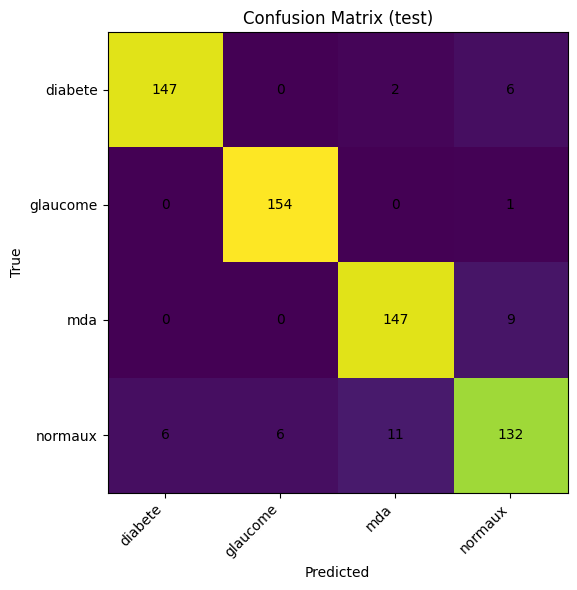

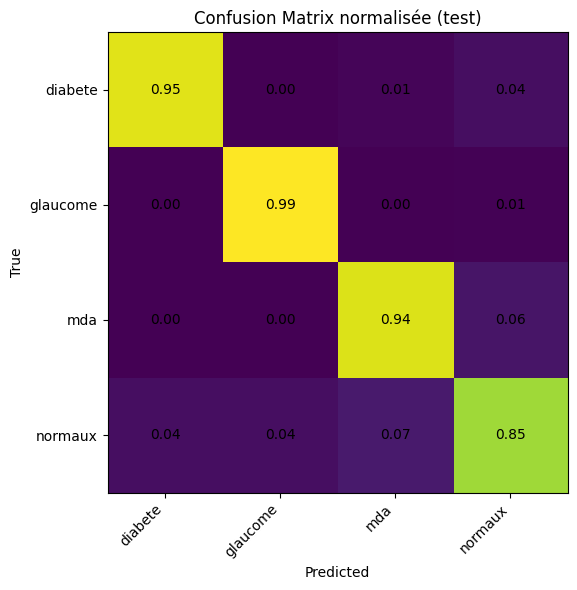


=== Classification report (test) ===
              precision    recall  f1-score   support

     diabete     0.9608    0.9484    0.9545       155
    glaucome     0.9625    0.9935    0.9778       155
         mda     0.9187    0.9423    0.9304       156
     normaux     0.8919    0.8516    0.8713       155

    accuracy                         0.9340       621
   macro avg     0.9335    0.9340    0.9335       621
weighted avg     0.9335    0.9340    0.9335       621



In [10]:
# -------------------------
# 7) Évaluation sur le test set
# -------------------------
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

model.load_state_dict(torch.load(best_model_path, map_location=device, weights_only=True))

def predict_on_loader(model, loader, device):
    model.eval()
    y_true, y_pred, y_proba = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device, non_blocking=True)
            probs = torch.softmax(model(x), dim=1)
            y_pred.append(probs.argmax(1).cpu().numpy())
            y_true.append(y.numpy())
            y_proba.append(probs.cpu().numpy())
    return np.concatenate(y_true), np.concatenate(y_pred), np.concatenate(y_proba)

def plot_confusion_matrix(cm, class_names, title="Confusion Matrix", normalize=False):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(cm)
    ax.set_xticks(np.arange(len(class_names))); ax.set_yticks(np.arange(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, f"{cm[i,j]:.2f}" if normalize else str(cm[i,j]), ha="center", va="center")
    plt.tight_layout(); plt.show()

y_true, y_pred, y_proba = predict_on_loader(model, test_loader, device)
cm = confusion_matrix(y_true, y_pred)

plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix (test)")
plot_confusion_matrix(cm, list(le.classes_), title="Confusion Matrix normalisée (test)", normalize=True)

print("\n=== Classification report (test) ===")
print(classification_report(y_true, y_pred, target_names=le.classes_, digits=4))


Nombre d'images mal classées : 41


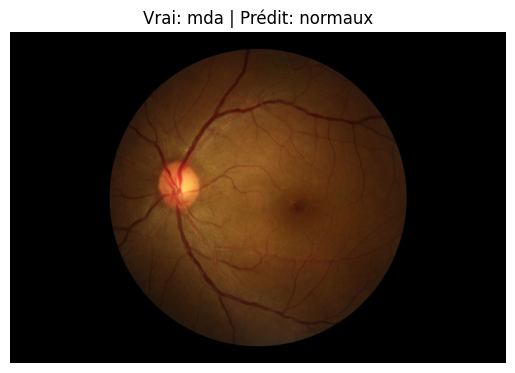

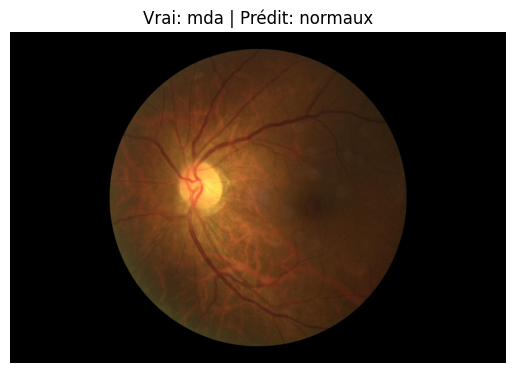

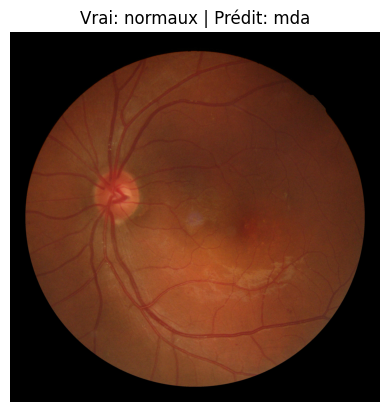

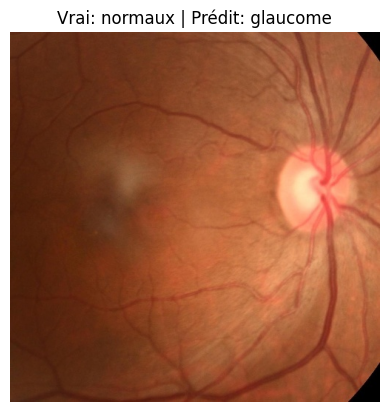

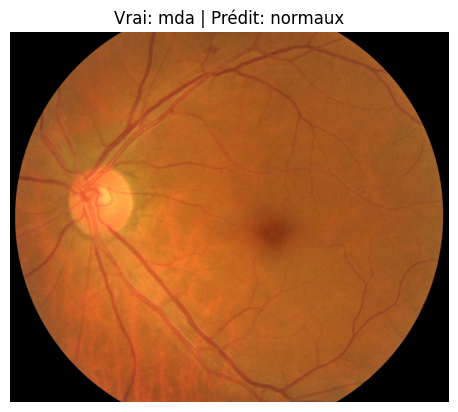

In [8]:
# -------------------------
# 8) Exemples d'images mal classées
# -------------------------
df_test = test_df.reset_index(drop=True)
classes = le.classes_
misclassified_indices = np.where(y_true != y_pred)[0]
print(f"Nombre d'images mal classées : {len(misclassified_indices)}")

for idx in misclassified_indices[:5]:
    img_path = df_test.iloc[idx]['path']
    true_label = classes[y_true[idx]]
    pred_label = classes[y_pred[idx]]
    img = Image.open(img_path).convert("RGB")
    plt.imshow(img)
    plt.title(f"Vrai: {true_label} | Prédit: {pred_label}")
    plt.axis("off")
    plt.show()